In [11]:
import kagglehub

path = kagglehub.competition_download('rs-18-track-b')

print("Path to competition files:", path)

Path to competition files: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-b


In [116]:
import os

for f in os.listdir(path):
    print(f)

sample_submission.csv
submission1_original.csv
submission2_cleansed_data.csv
submission3_cleansed_dataaugmentation.csv
submission4_efficient.csv
submission_efficient2.csv
submission_strategy_A.csv
submission_strategy_B.csv
submission_strategy_C.csv
submission_strategy_D.csv
test
train
train_labels.csv


In [13]:
import pandas as pd

train_labels = pd.read_csv(os.path.join(path, 'train_labels.csv'))
print(train_labels.shape)
train_labels.head()

(1366, 2)


,id,label
0,train_00000,0
1,train_00001,1
2,train_00002,0
3,train_00003,1
4,train_00004,1


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [15]:
# 컬럼 정보 확인
print(train_labels.info())
train_labels.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1366 entries, 0 to 1365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1366 non-null   object
 1   label   1366 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 21.5+ KB
None


id       object
label     int64
dtype: object

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image

In [117]:
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')

print('train 이미지 수:', len(os.listdir(train_dir)))
print('test 이미지 수:', len(os.listdir(test_dir)))

train 이미지 수: 1366
test 이미지 수: 468


In [9]:
# import matplotlib.pyplot as plt
# from PIL import Image

# sample_files = os.listdir(train_dir)[:9]

# fig, axes = plt.subplots(3, 3, figsize=(12,12))
# for ax, fname in zip(axes.flatten(), sample_files):
#     img = Image.open(os.path.join(train_dir, fname))
#     ax.imshow(img)
#     ax.set_title(fname)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

In [19]:
sizes = []
for fname in os.listdir(train_dir)[:100]:  # 일부만 샘플링
    img = Image.open(os.path.join(train_dir, fname))
    sizes.append(img.size)

print('이미지 크기 종류:', set(sizes))

이미지 크기 종류: {(512, 287), (511, 380), (341, 512), (80, 80), (512, 375), (300, 300), (512, 384), (512, 512), (512, 332), (389, 280), (512, 341), (261, 512), (512, 338), (319, 346), (503, 472), (300, 168), (512, 249), (274, 512), (512, 374), (384, 512), (512, 325), (512, 383), (100, 100), (512, 511), (500, 500), (512, 230), (512, 288), (250, 200), (236, 512), (512, 358), (512, 303), (274, 511), (480, 360), (512, 254), (512, 376), (512, 443), (512, 385), (512, 330), (512, 400), (240, 240)}


In [20]:
sizes = []
for fname in os.listdir(train_dir):
    img = Image.open(os.path.join(train_dir, fname))
    sizes.append(img.size)

from collections import Counter
print(Counter(sizes))

Counter({(384, 512): 375, (512, 384): 166, (512, 288): 106, (512, 341): 103, (512, 512): 86, (512, 375): 42, (274, 512): 23, (512, 340): 17, (512, 376): 14, (512, 230): 13, (512, 358): 13, (512, 383): 10, (100, 100): 10, (274, 511): 10, (80, 80): 10, (512, 287): 9, (512, 342): 8, (341, 512): 7, (512, 256): 7, (512, 322): 7, (512, 268): 7, (512, 249): 5, (512, 374): 5, (512, 303): 5, (500, 500): 5, (512, 401): 5, (512, 170): 5, (512, 418): 5, (512, 511): 4, (512, 404): 4, (512, 359): 4, (512, 343): 4, (512, 267): 4, (512, 199): 4, (512, 395): 4, (512, 289): 4, (512, 385): 3, (512, 330): 3, (236, 512): 3, (512, 311): 3, (512, 366): 3, (512, 370): 3, (512, 377): 3, (512, 345): 3, (511, 287): 3, (409, 512): 3, (511, 511): 3, (288, 512): 3, (512, 320): 3, (512, 412): 3, (359, 512): 3, (512, 307): 3, (512, 247): 3, (300, 300): 2, (512, 400): 2, (319, 346): 2, (240, 240): 2, (480, 360): 2, (512, 332): 2, (250, 200): 2, (300, 168): 2, (389, 280): 2, (503, 472): 2, (244, 484): 2, (512, 248): 2,

In [21]:
import numpy as np



target_col = train_labels.columns[-1]
id_col = train_labels.columns[0]
def get_mean_brightness(img_path):
    img = np.array(Image.open(img_path).convert('L'))
    return img.mean()

train_labels['brightness'] = train_labels[id_col].apply(
    lambda x: get_mean_brightness(os.path.join(train_dir, x if str(x).endswith('.jpg') else f'{x}.jpg'))
)

train_labels.groupby(target_col)['brightness'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,813.0,117.497461,23.949201,41.224040,102.907511,117.154056,130.716548,223.019111
1,553.0,119.531387,21.959915,16.840969,106.418447,118.794735,132.174015,196.711616


In [22]:
# !pip install -q imagehash

In [23]:
import imagehash
from PIL import Image

hashes = {}
for fname in os.listdir(train_dir):
    img = Image.open(os.path.join(train_dir, fname))
    h = imagehash.phash(img)
    hashes[fname] = h

# 비슷한 해시(거의 동일한 이미지) 찾기
from collections import defaultdict
groups = defaultdict(list)
fnames = list(hashes.keys())

for i in range(len(fnames)):
    for j in range(i+1, len(fnames)):
        dist = hashes[fnames[i]] - hashes[fnames[j]]
        if dist <= 5:  # 임계값, 작을수록 유사
            groups[fnames[i]].append((fnames[j], dist))

print(f'유사 이미지 쌍 후보 수: {sum(len(v) for v in groups.values())}')

유사 이미지 쌍 후보 수: 71


72개라면 전체 이미지가 약 1370개 정도였으니 5% 내외가 중복 후보라는 거고,  "중복 이미지" 문제가 실제로 데이터에 존재한다는 게 확인

In [8]:
# # groups를 거리 기준으로 정렬해서 가장 유사한 쌍부터 확인
# all_pairs = []
# for fname1, matches in groups.items():
#     for fname2, dist in matches:
#         all_pairs.append((fname1, fname2, dist))

# all_pairs.sort(key=lambda x: x[2])

# # 상위 6쌍 시각화
# fig, axes = plt.subplots(6, 2, figsize=(8, 24))
# for i, (f1, f2, dist) in enumerate(all_pairs[:6]):
#     img1 = Image.open(os.path.join(train_dir, f1))
#     img2 = Image.open(os.path.join(train_dir, f2))
#     axes[i,0].imshow(img1)
#     axes[i,0].set_title(f'{f1}')
#     axes[i,1].imshow(img2)
#     axes[i,1].set_title(f'{f2} (dist={dist})')
#     axes[i,0].axis('off')
#     axes[i,1].axis('off')

# plt.tight_layout()
# plt.show()

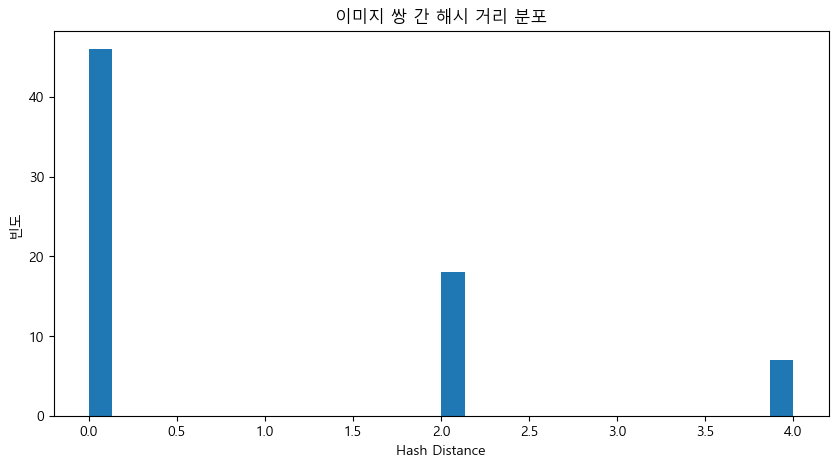

count    71.000000
mean      0.901408
std       1.343289
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max       4.000000
dtype: float64


In [25]:
all_dists = [d for matches in groups.values() for f2, d in matches]

plt.figure(figsize=(10,5))
plt.hist(all_dists, bins=30)
plt.xlabel('Hash Distance')
plt.ylabel('빈도')
plt.title('이미지 쌍 간 해시 거리 분포')
plt.show()

print(pd.Series(all_dists).describe())

- 거리값이 0, 2, 4 세 군데에만 몰려있고, 최댓값이 4로 임계값 5보다 작습니다. 즉 지금 잡은 72개 쌍은 전부 거리 0-4 사이의 "확실한" 중복들이고, 애매한 경계선 케이스(거리 5~7 정도의 모호한 유사 이미지)는 아직 탐색되지 않은 상태

- 평균 0.94, 표준편차 1.38 정도면 전반적으로 매우 가까운 거리에 쌍들이 몰려있어서, 임계값 5는 너무 빡빡하다기보다는 "확실한 중복만 잡고 경계선은 놓쳤을 가능성"이 있는 상태입니다. 임계값을 좀 더 넓혀서(예: 8-10) 추가로 어떤 쌍들이 잡히는지 보고, 그게 진짜 중복인지 그냥 비슷한 패널 사진인지 확인

threshold=10일 때 후보 쌍 수: 101


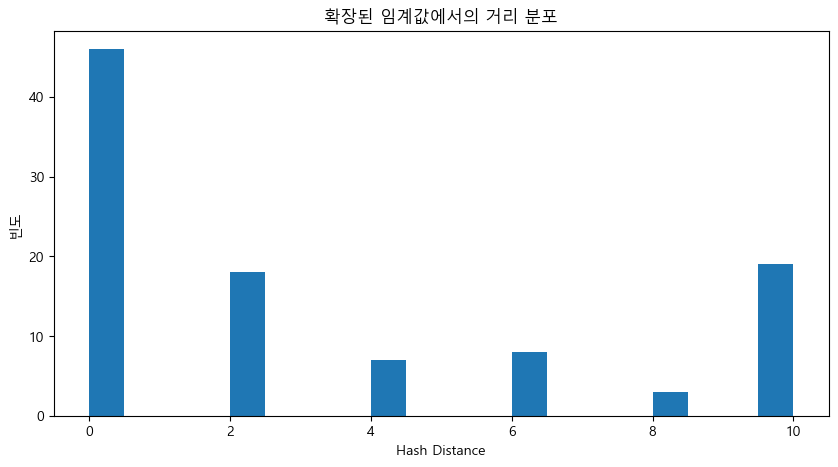

In [26]:
# 임계값을 10으로 확장

threshold = 10  # 기존 5에서 확장

groups_wide = defaultdict(list)
for i in range(len(fnames)):
    for j in range(i+1, len(fnames)):
        dist = hashes[fnames[i]] - hashes[fnames[j]]
        if dist <= threshold:
            groups_wide[fnames[i]].append((fnames[j], dist))

all_pairs_wide = [(f1, f2, d) for f1, matches in groups_wide.items() for f2, d in matches]
print(f'threshold={threshold}일 때 후보 쌍 수: {len(all_pairs_wide)}')

# 거리별 분포 다시 확인
all_dists_wide = [d for f1,f2,d in all_pairs_wide]
plt.figure(figsize=(10,5))
plt.hist(all_dists_wide, bins=20)
plt.xlabel('Hash Distance')
plt.ylabel('빈도')
plt.title('확장된 임계값에서의 거리 분포')
plt.show()

후보가 72개에서 100개로 늘었는데, 분포를 보면 몇 가지 특징이 보입니다.
거리 0, 2, 4 구간은 이전과 동일하게 유지되고, 6 구간에 7개, 8 구간에 3개가 추가로 나타났습니다. 그런데 거리 10 구간에서 갑자기 18개가 튀어 올라온 게 눈에 띕니다. 이건 자연스러운 감소 패턴이 아니라서, 진짜 유사 이미지라기보다 "우연히 해시값이 비슷해진 무작위 매칭"일 가능성이 있습니다. pHash는 64비트 해시라서, 전혀 다른 이미지라도 일정 비율은 거리 10 근처에서 우연히 걸릴 수 있습니다.

In [7]:
# # 거리 6~8 구간 확인 (진짜 중복일 가능성이 있는 경계선)
# mid_pairs = [(f1,f2,d) for f1,f2,d in all_pairs_wide if 6 <= d <= 8]
# print(f'거리 6~8 쌍 수: {len(mid_pairs)}')

# fig, axes = plt.subplots(min(5,len(mid_pairs)), 2, figsize=(8, 4*min(5,len(mid_pairs))))
# for i, (f1, f2, dist) in enumerate(mid_pairs[:5]):
#     img1 = Image.open(os.path.join(train_dir, f1))
#     img2 = Image.open(os.path.join(train_dir, f2))
#     axes[i,0].imshow(img1)
#     axes[i,0].set_title(f1)
#     axes[i,1].imshow(img2)
#     axes[i,1].set_title(f'{f2} (dist={dist})')
#     axes[i,0].axis('off')
#     axes[i,1].axis('off')
# plt.tight_layout()
# plt.show()

In [6]:
# # 거리 10 구간 확인 (우연한 매칭 의심)
# far_pairs = [(f1,f2,d) for f1,f2,d in all_pairs_wide if d == 10]
# print(f'거리 10 쌍 수: {len(far_pairs)}')

# fig, axes = plt.subplots(min(5,len(far_pairs)), 2, figsize=(8, 4*min(5,len(far_pairs))))
# for i, (f1, f2, dist) in enumerate(far_pairs[:5]):
#     img1 = Image.open(os.path.join(train_dir, f1))
#     img2 = Image.open(os.path.join(train_dir, f2))
#     axes[i,0].imshow(img1)
#     axes[i,0].set_title(f1)
#     axes[i,1].imshow(img2)
#     axes[i,1].set_title(f'{f2} (dist={dist})')
#     axes[i,0].axis('off')
#     axes[i,1].axis('off')
# plt.tight_layout()
# plt.show()

In [29]:
# dup_df생성

fname_list = list(hashes.keys())
min_dist_dict = {}

for i, f1 in enumerate(fname_list):
    min_d = 999
    for j, f2 in enumerate(fname_list):
        if f1 == f2:
            continue
        d = hashes[f1] - hashes[f2]
        if d < min_d:
            min_d = d
    min_dist_dict[f1] = min_d

dup_df = pd.DataFrame(list(min_dist_dict.items()), columns=['fname', 'min_hash_dist'])
print(dup_df.shape)
dup_df.head()

(1366, 2)


,fname,min_hash_dist
0,train_00000.jpg,18
1,train_00001.jpg,18
2,train_00002.jpg,18
3,train_00003.jpg,20
4,train_00004.jpg,18


In [30]:
# 시그모이드 점수 부여

import numpy as np

def dist_to_score_sigmoid(dist, midpoint=9, steepness=1.0):
    return 1 / (1 + np.exp(steepness * (dist - midpoint)))

dup_df['dup_score'] = dup_df['min_hash_dist'].apply(dist_to_score_sigmoid)
dup_df.sort_values('dup_score', ascending=False).head(20)

,fname,min_hash_dist,dup_score
229,train_00229.jpg,0,0.999877
965,train_00965.jpg,0,0.999877
635,train_00635.jpg,0,0.999877
1209,train_01209.jpg,0,0.999877
624,train_00624.jpg,0,0.999877
956,train_00956.jpg,0,0.999877
1202,train_01202.jpg,0,0.999877
1198,train_01198.jpg,0,0.999877
860,train_00860.jpg,0,0.999877
1191,train_01191.jpg,0,0.999877


In [31]:
## dup_score를 순위 기반으로 단순화


# 거리가 작을수록(=더 유사할수록) 점수가 높아야 함
dup_df['dup_score'] = -dup_df['min_hash_dist']  # 음수로 뒤집기만 해도 순위는 동일

# 또는 0~1 범위로 보기 좋게 정규화하고 싶다면
dup_df['dup_score_norm'] = (dup_df['min_hash_dist'].max() - dup_df['min_hash_dist']) / (dup_df['min_hash_dist'].max() - dup_df['min_hash_dist'].min())

dup_df.sort_values('dup_score', ascending=False).head(10)

,fname,min_hash_dist,dup_score,dup_score_norm
229,train_00229.jpg,0,0,1.0
965,train_00965.jpg,0,0,1.0
635,train_00635.jpg,0,0,1.0
1209,train_01209.jpg,0,0,1.0
624,train_00624.jpg,0,0,1.0
956,train_00956.jpg,0,0,1.0
1202,train_01202.jpg,0,0,1.0
1198,train_01198.jpg,0,0,1.0
860,train_00860.jpg,0,0,1.0
1191,train_01191.jpg,0,0,1.0


In [32]:
## 자체검증

# 직접 눈으로 확인했던 진짜 중복 이미지들
known_dups = ['train_00007.jpg', 'train_00301.jpg', 'train_00086.jpg', 'train_01205.jpg',
              'train_00257.jpg', 'train_01055.jpg', 'train_00236.jpg']

dup_df_sorted = dup_df.sort_values('dup_score', ascending=False).reset_index(drop=True)
dup_df_sorted['rank'] = dup_df_sorted.index + 1

for f in known_dups:
    row = dup_df_sorted[dup_df_sorted['fname'] == f]
    if not row.empty:
        print(f"{f}: rank {row['rank'].values[0]} / {len(dup_df_sorted)}, dist={row['min_hash_dist'].values[0]}")

train_00007.jpg: rank 141 / 1366, dist=6
train_00301.jpg: rank 146 / 1366, dist=6
train_00086.jpg: rank 159 / 1366, dist=8
train_01205.jpg: rank 160 / 1366, dist=8
train_00257.jpg: rank 179 / 1366, dist=10
train_01055.jpg: rank 185 / 1366, dist=10
train_00236.jpg: rank 174 / 1366, dist=10


- 전체 1366개 중 145 - 187위면 상위 약 10-14% 구간임. AP 평가에서는 이 정도면 나쁘지 않지만, "확실한 진짜 중복"이라고 직접 확인한 이미지들 치고는 더 위로(예: 상위 1~5%) 올라와야 이상적.
- 145위라는 건 이 이미지들보다 더 낮은 거리(dist < 6)를 가진 이미지가 144개나 있다는 뜻인데, 분포 그래프를 보면 거리 0~4 구간에만 이미 46+18+8=72개가 있었으니 그게 어느 정도 설명이 됨

- 하나는 정상적인 현상입니다. 데이터셋에 진짜 중복 쌍이 여러 그룹 있다면, 거리 0~4인 "더 강한 중복"들이 144개 있어도 이상하지 않음. 즉 known_dups보다 더 확실한 중복들이 많이 존재한다는 뜻.

- 다른 하나는 우려되는 현상입니다. 거리 10 구간에서 봤던 것처럼, pHash가 우연히 비슷한 값을 내는 "가짜 유사" 이미지들이 거리 0~4 구간에도 섞여 있을 가능성. 즉 144개 중 일부는 실제로는 중복이 아닌데 우연히 해시가 가까운 경우일 수 있음.

- 이걸 구분하려면 거리 0~4 구간에서 무작위로 몇 쌍을 뽑아 실제로 진짜 중복인지 다시 확인

In [5]:
# # 거리 0~4인 쌍 중 무작위 샘플 확인
# close_pairs = [(f1,f2,d) for f1,f2,d in all_pairs_wide if d <= 4]
# print(f'거리 0~4 쌍 수: {len(close_pairs)}')

# import random
# random.seed(42)
# sample_pairs = random.sample(close_pairs, min(5, len(close_pairs)))

# fig, axes = plt.subplots(len(sample_pairs), 2, figsize=(8, 4*len(sample_pairs)))
# for i, (f1, f2, dist) in enumerate(sample_pairs):
#     img1 = Image.open(os.path.join(train_dir, f1))
#     img2 = Image.open(os.path.join(train_dir, f2))
#     axes[i,0].imshow(img1)
#     axes[i,0].set_title(f1)
#     axes[i,1].imshow(img2)
#     axes[i,1].set_title(f'{f2} (dist={dist})')
#     axes[i,0].axis('off')
#     axes[i,1].axis('off')
# plt.tight_layout()
# plt.show()

- 거리 0-4 구간도 전부 명확한 진짜 중복으로 확인됐습니다. pHash가 신뢰할 만하다는 게 검증.
- known_dups의 순위가 145-187위로 나온 이유가 설명됨 우려했던 가짜 유사 문제가 아니라, 단순히 이 데이터셋에 진짜 중복 쌍/그룹이 생각보다 많아서(거리 0~4 구간에만 72개) known_dups보다 더 강한 매칭들이 자연스럽게 더 위쪽 순위를 차지하고 있는 것임 즉 dup_score는 정상적으로 작동하고 있다고 판단


# dup_score 확정

In [34]:
dup_df['dup_score'] = -dup_df['min_hash_dist']
dup_df_final = dup_df[['fname', 'dup_score']].copy()
dup_df_final.head()

,fname,dup_score
0,train_00000.jpg,-18
1,train_00001.jpg,-18
2,train_00002.jpg,-18
3,train_00003.jpg,-20
4,train_00004.jpg,-18


## 2. ood_score 작업

In [35]:
# ===== 환경 설정 셀 (항상 맨 먼저 실행) =====
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_25f30858b24762bcbb5c33cee911001d'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import kagglehub
path = kagglehub.competition_download('rs-18-track-b')

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
train_labels = pd.read_csv(os.path.join(path, 'train_labels.csv'))

print('환경 설정 완료:', path)

환경 설정 완료: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-b


In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import kagglehub
path = kagglehub.competition_download('rs-18-track-b')

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
train_labels = pd.read_csv(os.path.join(path, 'train_labels.csv'))

print('복구 완료:', path)

복구 완료: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-b


In [37]:
import torch
from torchvision import models, transforms

model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

embeddings = {}
with torch.no_grad():
    for fname in os.listdir(train_dir):
        img = Image.open(os.path.join(train_dir, fname)).convert('RGB')
        x = transform(img).unsqueeze(0)
        emb = model(x).squeeze().numpy()
        embeddings[fname] = emb

print(f'임베딩 추출 완료: {len(embeddings)}개')

c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


임베딩 추출 완료: 1366개


centroid로부터의 거리 계산

In [38]:
import numpy as np

fname_list = list(embeddings.keys())
emb_matrix = np.array([embeddings[f] for f in fname_list])

centroid = emb_matrix.mean(axis=0)
distances = np.linalg.norm(emb_matrix - centroid, axis=1)

ood_df = pd.DataFrame({'fname': fname_list, 'centroid_dist': distances})
ood_df = ood_df.sort_values('centroid_dist', ascending=False)
ood_df.head(20)

,fname,centroid_dist
763,train_00763.jpg,26.424078
288,train_00288.jpg,25.653175
60,train_00060.jpg,25.482546
29,train_00029.jpg,24.328886
410,train_00410.jpg,24.301678
1085,train_01085.jpg,24.205685
424,train_00424.jpg,24.171198
73,train_00073.jpg,23.955187
193,train_00193.jpg,23.863008
431,train_00431.jpg,23.764246


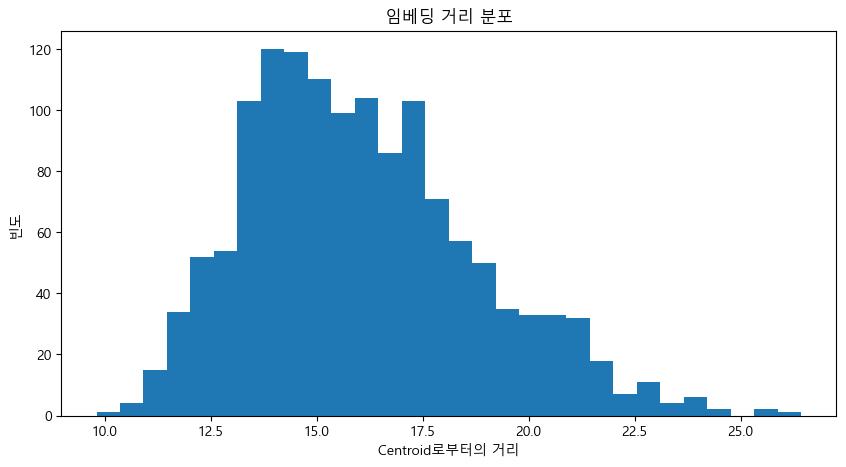

count    1366.000000
mean       16.091799
std         2.708147
min         9.809464
25%        14.075172
50%        15.743212
75%        17.766573
max        26.424078
Name: centroid_dist, dtype: float64


In [39]:
plt.figure(figsize=(10,5))
plt.hist(ood_df['centroid_dist'], bins=30)
plt.xlabel('Centroid로부터의 거리')
plt.ylabel('빈도')
plt.title('임베딩 거리 분포')
plt.show()

print(ood_df['centroid_dist'].describe())

거리 상위 이미지 시각화

In [4]:
# top_ood = ood_df.head(9)['fname'].tolist()

# fig, axes = plt.subplots(3, 3, figsize=(12,12))
# for ax, fname in zip(axes.flatten(), top_ood):
#     img = Image.open(os.path.join(train_dir, fname))
#     ax.imshow(img)
#     ax.set_title(fname)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

- 이미지들은 진짜 OOD(패널 위에서 작업하는 사람, 태양광 패널 부품)는 아니고, 모두 태양광 패널과 관련은 있지만 성격이 다른 이미지들임

In [3]:
# # KNN 기반 거리도 계산해서 비교

# from sklearn.neighbors import NearestNeighbors

# k = 5
# nbrs = NearestNeighbors(n_neighbors=k+1).fit(emb_matrix)
# dists, idxs = nbrs.kneighbors(emb_matrix)
# knn_dist = dists[:, 1:].mean(axis=1)

# ood_df['knn_dist'] = knn_dist
# ood_df_knn = ood_df.sort_values('knn_dist', ascending=False)

# top_ood_knn = ood_df_knn.head(20)['fname'].tolist()

# fig, axes = plt.subplots(4, 5, figsize=(18,15))
# for ax, fname in zip(axes.flatten(), top_ood_knn):
#     img = Image.open(os.path.join(train_dir, fname))
#     ax.imshow(img)
#     ax.set_title(fname, fontsize=9)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

- KNN 결과에는 인포그래픽/카탈로그 이미지가 거의 없고, 다른 패턴이 보임.작업자가 직접 설치하는 사진(헬멧 쓴 인부가 패널 작업 중인 장면)이 여러 장 있고, train_00115처럼 "DIRTY"라는 워터마크가 큼직하게 박힌 이미지, 그리고 일반적인 설치 사진들도 섞여 있음.
- centroid 거리는 전체 평균에서 얼마나 멀리 떨어져 있는가를 보기 때문에, 카탈로그 이미지처럼 극단적으로 다른 스타일(텍스트, 도식)이 1등으로 잡힘(전체와 이질감 측정).
- 반면 KNN 거리는 가장 가까운 이웃들과도 얼마나 떨어져 있는가를 보기 때문에, 비슷한 이미지가 거의 없는 희귀한 구도나 워터마크가 있는 이미지가 더 잘 잡힘(고립된 정도).
- 두 결과 모두 명백한 OOD(사람만 나온 사진, 동물, 완전히 무관한 풍경)는 안 보이고, 둘 다 "패널 사진이긴 한데 뭔가 특이한 케이스"를 잡아낸다는 공통점이 있지만 그 "특이함"의 종류가 다름.
- 이걸 보면 이 데이터셋에는 극단적인 OOD(완전히 다른 대상)보다는, 패널이 등장하지만 정상적인 "패널 단독 촬영"과는 다른 성격의 이미지(인포그래픽, 사람이 작업 중인 장면, 워터마크/텍스트가 박힌 이미지)들이 의심 후보로 자리 잡고 있다고 보는 게 맞을 것 같음.

- centroid와 KNN 둘 다 일리가 있지만 잡아내는 게 다르기 때문에, 둘을 합치는 게 더 안정적인 ood_score를 만드는 방법일 수 있음. 두 점수를 정규화해서 평균을 내거나, 둘 중 더 높은 순위를 채택하는 방식

In [42]:
from scipy.stats import rankdata

# 두 거리를 각각 순위로 변환 (거리가 클수록 OOD score가 높아야 함)
ood_df['centroid_rank'] = rankdata(ood_df['centroid_dist'])
ood_df['knn_rank'] = rankdata(ood_df['knn_dist'])

# 두 순위의 평균을 최종 ood_score로 사용
ood_df['ood_score'] = (ood_df['centroid_rank'] + ood_df['knn_rank']) / 2

ood_df_final = ood_df.sort_values('ood_score', ascending=False)
ood_df_final.head(20)

,fname,centroid_dist,knn_dist,centroid_rank,knn_rank,ood_score
1059,train_01059.jpg,22.759333,22.812735,1346.0,1364.0,1355.0
1085,train_01085.jpg,24.205685,20.273914,1361.0,1339.0,1350.0
1301,train_01301.jpg,21.425922,22.256449,1314.0,1362.0,1338.0
919,train_00919.jpg,21.759628,19.880125,1329.0,1328.0,1328.5
238,train_00238.jpg,21.161816,21.588963,1300.0,1357.0,1328.5
358,train_00358.jpg,21.030941,21.910542,1290.0,1359.0,1324.5
435,train_00435.jpg,20.828764,20.401841,1281.0,1343.0,1312.0
170,train_00170.jpg,21.358139,19.538431,1309.0,1312.0,1310.5
410,train_00410.jpg,24.301678,18.412502,1362.0,1253.0,1307.5
1200,train_01200.jpg,21.065826,19.334836,1293.0,1301.0,1297.0


In [2]:
# # 합쳐진 결과 시각화로 재확인
# top_combined = ood_df_final.head(20)['fname'].tolist()

# fig, axes = plt.subplots(4, 5, figsize=(18,15))
# for ax, fname in zip(axes.flatten(), top_combined):
#     img = Image.open(os.path.join(train_dir, fname))
#     ax.imshow(img)
#     ax.set_title(fname, fontsize=9)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

In [44]:
print(ood_df.shape)
ood_df.head()

(1366, 6)


,fname,centroid_dist,knn_dist,centroid_rank,knn_rank,ood_score
763,train_00763.jpg,26.424078,16.758324,1366.0,1114.0,1240.0
288,train_00288.jpg,25.653175,13.688197,1365.0,440.0,902.5
60,train_00060.jpg,25.482546,12.334653,1364.0,165.0,764.5
29,train_00029.jpg,24.328886,17.592287,1363.0,1189.0,1276.0
410,train_00410.jpg,24.301678,18.412502,1362.0,1253.0,1307.5


In [45]:
# !pip install -q pytesseract

In [46]:
# !apt-get install -y tesseract-ocr -q

In [47]:
import pytesseract

def get_text_ratio(img_path):
    img = Image.open(img_path).convert('RGB')
    text = pytesseract.image_to_string(img)
    return len(text.strip())

text_lengths = {}
for fname in os.listdir(train_dir):
    text_lengths[fname] = get_text_ratio(os.path.join(train_dir, fname))

ood_df['text_length'] = ood_df['fname'].map(text_lengths)
ood_df.sort_values('text_length', ascending=False).head(20)

,fname,centroid_dist,knn_dist,centroid_rank,knn_rank,ood_score,text_length
288,train_00288.jpg,25.653175,13.688197,1365.0,440.0,902.5,159
171,train_00171.jpg,17.163990,12.445129,931.0,181.0,556.0,156
60,train_00060.jpg,25.482546,12.334653,1364.0,165.0,764.5,153
410,train_00410.jpg,24.301678,18.412502,1362.0,1253.0,1307.5,120
659,train_00659.jpg,16.685667,22.481291,852.0,1363.0,1107.5,108
29,train_00029.jpg,24.328886,17.592287,1363.0,1189.0,1276.0,96
817,train_00817.jpg,19.459059,21.661143,1196.0,1358.0,1277.0,86
1026,train_01026.jpg,12.905401,12.205757,137.0,134.0,135.5,82
76,train_00076.jpg,22.925344,16.165671,1347.0,1018.0,1182.5,72
375,train_00375.jpg,14.625938,15.820547,462.0,940.0,701.0,64


- 지금까지 만든 ood_score(centroid_dist, knn_dist)는 ResNet 임베딩이 전형적인 패널 사진과 시각적으로 얼마나 다른가"를 측정하는 방식.
- 이 방식의 한계가 작업자가 패널을 설치하는 사진이나 물청소하는 사진처럼, 패널이 화면 중심에 명확히 보이고 clean/dusty 판단이 충분히 가능한 정상 이미지인데도, 구도가 좀 특이하다는 이유만으로 OOD 후보 상위권에 잘못 들어가는 경우가 많음(오탐).
- 프로젝트에서 진짜 OOD 후보들(train_00060 인포그래픽, train_00849 브랜드 로고 제품샷, train_00115 워터마크로 화면이 덮인 이미지)을 보면 공통된 특징은 화면에 글자가 많다는 점.
- 즉 이미지 안에 텍스트가 얼마나 많은가라는 신호 하나만 추가해도, 임베딩 - 거리만으로는 구분하기 어려웠던 진짜 OOD(그래픽/광고성 이미지)"와 "정상인데 구도가 특이한 이미지"를 더 정확하게 갈라낼 수 있을 거라는 가설
- OCR로 텍스트를 추출해서 그 길이를 점수에 반영하면, 인포그래픽/제품샷/워터마크 이미지들의 순위가 더 위로 올라가고, 작업자 사진이나 물청소 사진처럼 텍스트가 거의 없는 정상 이미지들의 순위는 자연스럽게 내려가게 됨.

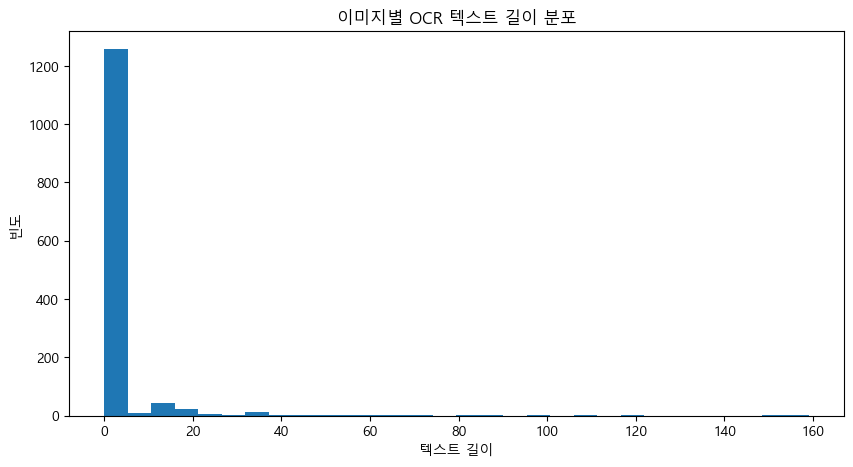

count    1366.000000
mean        2.208638
std        11.243673
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       159.000000
Name: text_length, dtype: float64


In [48]:
plt.figure(figsize=(10,5))
plt.hist(ood_df['text_length'], bins=30)
plt.xlabel('텍스트 길이')
plt.ylabel('빈도')
plt.title('이미지별 OCR 텍스트 길이 분포')
plt.show()

print(ood_df['text_length'].describe())

In [49]:
from scipy.stats import rankdata

ood_df['text_rank'] = rankdata(ood_df['text_length'])

ood_df['ood_score_v2'] = (ood_df['centroid_rank'] + ood_df['knn_rank'] + ood_df['text_rank']) / 3

ood_df_v2 = ood_df.sort_values('ood_score_v2', ascending=False)
ood_df_v2.head(20)

,fname,centroid_dist,knn_dist,centroid_rank,knn_rank,ood_score,text_length,text_rank,ood_score_v2
1301,train_01301.jpg,21.425922,22.256449,1314.0,1362.0,1338.0,15,1304.0,1326.666667
410,train_00410.jpg,24.301678,18.412502,1362.0,1253.0,1307.5,120,1363.0,1326.000000
817,train_00817.jpg,19.459059,21.661143,1196.0,1358.0,1277.0,86,1360.0,1304.666667
29,train_00029.jpg,24.328886,17.592287,1363.0,1189.0,1276.0,96,1361.0,1304.333333
763,train_00763.jpg,26.424078,16.758324,1366.0,1114.0,1240.0,13,1285.0,1255.000000
1106,train_01106.jpg,20.378061,17.117866,1254.0,1157.0,1205.5,31,1339.0,1250.000000
1258,train_01258.jpg,19.324667,19.036866,1188.0,1286.0,1237.0,12,1269.5,1247.833333
994,train_00994.jpg,19.643236,18.487890,1206.0,1258.0,1232.0,12,1269.5,1244.500000
76,train_00076.jpg,22.925344,16.165671,1347.0,1018.0,1182.5,72,1358.0,1241.000000
78,train_00078.jpg,20.118820,16.784563,1238.0,1118.0,1178.0,34,1347.0,1234.333333


종합 점수 상위 20개 시각화

종합 ood_score_v2 계산

In [1]:
# top_v2 = ood_df_v2.head(20)['fname'].tolist()

# fig, axes = plt.subplots(4, 5, figsize=(18,15))
# for ax, fname in zip(axes.flatten(), top_v2):
#     img = Image.open(os.path.join(train_dir, fname))
#     ax.imshow(img)
#     ax.set_title(fname, fontsize=9)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

In [51]:
# train_00009의 현재 순위 확인
row = ood_df_v2.reset_index(drop=True)
row['rank'] = row.index + 1
print(row[row['fname']=='train_00009.jpg'][['fname','centroid_rank','knn_rank','text_rank','ood_score_v2','rank']])

               fname  centroid_rank  knn_rank  text_rank  ood_score_v2  rank
141  train_00009.jpg         1301.0     909.0      624.5    944.833333   142


전체 1366개 중 35위(2.6%)면 꽤 잘 작동하는 것으로 보임  

검증내용 정리

1. 인포그래픽/제품샷/워터마크 이미지: 텍스트 신호 덕분에 최상위권(1~20위)에 정확히 포착됨
2. 패널 부재형 이미지(train_00009): 임베딩 거리 신호로 35위에 포착됨
3. 두 가지 다른 유형의 OOD가 모두 합리적인 순위를 받고 있음

# ood_score 확정

In [52]:
ood_df_final = ood_df[['fname', 'ood_score_v2']].rename(columns={'ood_score_v2': 'ood_score'})
ood_df_final.head()

,fname,ood_score
763,train_00763.jpg,1255.000000
288,train_00288.jpg,1057.000000
60,train_00060.jpg,964.333333
29,train_00029.jpg,1304.333333
410,train_00410.jpg,1326.000000


# 3. mislabel_score
K-fold 교차검증으로 각 이미지의 예측 확률 산출

- 프로젝트의 mislable 정의에 따르면 cleanlab의 Confident Learning이 다루는 표준 케이스에 해당. 이미지 자체는 정상(중복도 OOD도 아님)인데 라벨만 뒤바뀐 경우를 찾는 거라서 접근 방식을 그대로 진행.
- 다만 mislabel_score를 계산할 때 이미 dup_score나 ood_score가 높은 이미지(중복이거나 off-topic인 이미지)는 애초에 "이미지가 멀쩡한" 경우가 아니므로, mislabel 판단 대상에서 혼동을 줄 수 있음. 이 부분은 모델 학습 자체에는 큰 영향이 없지만, 최종 해석 단계에서 참고

In [124]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import StratifiedKFold
import numpy as np

target_col = train_labels.columns[-1]
id_col = train_labels.columns[0]

# 파일명 정리
train_labels['fname'] = train_labels[id_col].apply(
    lambda x: x if str(x).endswith('.jpg') else f'{x}.jpg'
)

class PanelDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['fname'])).convert('RGB')
        img = self.transform(img)
        label = int(row[target_col])
        return img, label

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)

사용 디바이스: cuda


K-fold 학습 루프

In [54]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

pred_probs = np.zeros((len(train_labels), 2))  # 클래스 2개 (clean/dusty)

for fold, (train_idx, val_idx) in enumerate(skf.split(train_labels, train_labels[target_col])):
    print(f'Fold {fold+1}/{n_splits}')

    train_df = train_labels.iloc[train_idx]
    val_df = train_labels.iloc[val_idx]

    train_ds = PanelDataset(train_df, train_dir, transform)
    val_ds = PanelDataset(val_df, train_dir, transform)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # 간단히 3 epoch만 학습 (베이스라인 수준)
    model.train()
    for epoch in range(3):
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f'  Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}')

    # 검증셋 예측 확률 저장
    model.eval()
    with torch.no_grad():
        idx_pointer = 0
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            batch_size = probs.shape[0]
            original_indices = val_idx[idx_pointer: idx_pointer+batch_size]
            pred_probs[original_indices] = probs
            idx_pointer += batch_size

print('K-fold 예측 완료')

Fold 1/5


c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1, Loss: 0.6161
  Epoch 2, Loss: 0.2253
  Epoch 3, Loss: 0.0870
Fold 2/5
  Epoch 1, Loss: 0.6405
  Epoch 2, Loss: 0.2528
  Epoch 3, Loss: 0.1002
Fold 3/5
  Epoch 1, Loss: 0.6081
  Epoch 2, Loss: 0.2245
  Epoch 3, Loss: 0.1013
Fold 4/5
  Epoch 1, Loss: 0.6173
  Epoch 2, Loss: 0.2150
  Epoch 3, Loss: 0.1123
Fold 5/5
  Epoch 1, Loss: 0.6660
  Epoch 2, Loss: 0.2367
  Epoch 3, Loss: 0.1366
K-fold 예측 완료


cleanlab으로 라벨 오류 점수 계산

In [127]:
from cleanlab.rank import get_label_quality_scores

labels = train_labels[target_col].values

quality_scores = get_label_quality_scores(labels=labels, pred_probs=pred_probs)

# 품질 점수가 낮을수록 라벨 오류 의심 -> mislabel_score는 반대로 변환
train_labels['label_quality'] = quality_scores
train_labels['mislabel_score'] = 1 - quality_scores

train_labels.sort_values('mislabel_score', ascending=False).head(20)

,id,label,fname,label_quality,mislabel_score
1177,train_01177,1,train_01177.jpg,0.000388,0.999612
244,train_00244,1,train_00244.jpg,0.000450,0.999550
1244,train_01244,1,train_01244.jpg,0.000591,0.999409
1033,train_01033,1,train_01033.jpg,0.000933,0.999067
353,train_00353,1,train_00353.jpg,0.001528,0.998472
763,train_00763,1,train_00763.jpg,0.001727,0.998273
1082,train_01082,1,train_01082.jpg,0.001754,0.998246
519,train_00519,1,train_00519.jpg,0.001874,0.998126
1135,train_01135,1,train_01135.jpg,0.002019,0.997981
395,train_00395,1,train_00395.jpg,0.002292,0.997708


이미지 시각화 검증

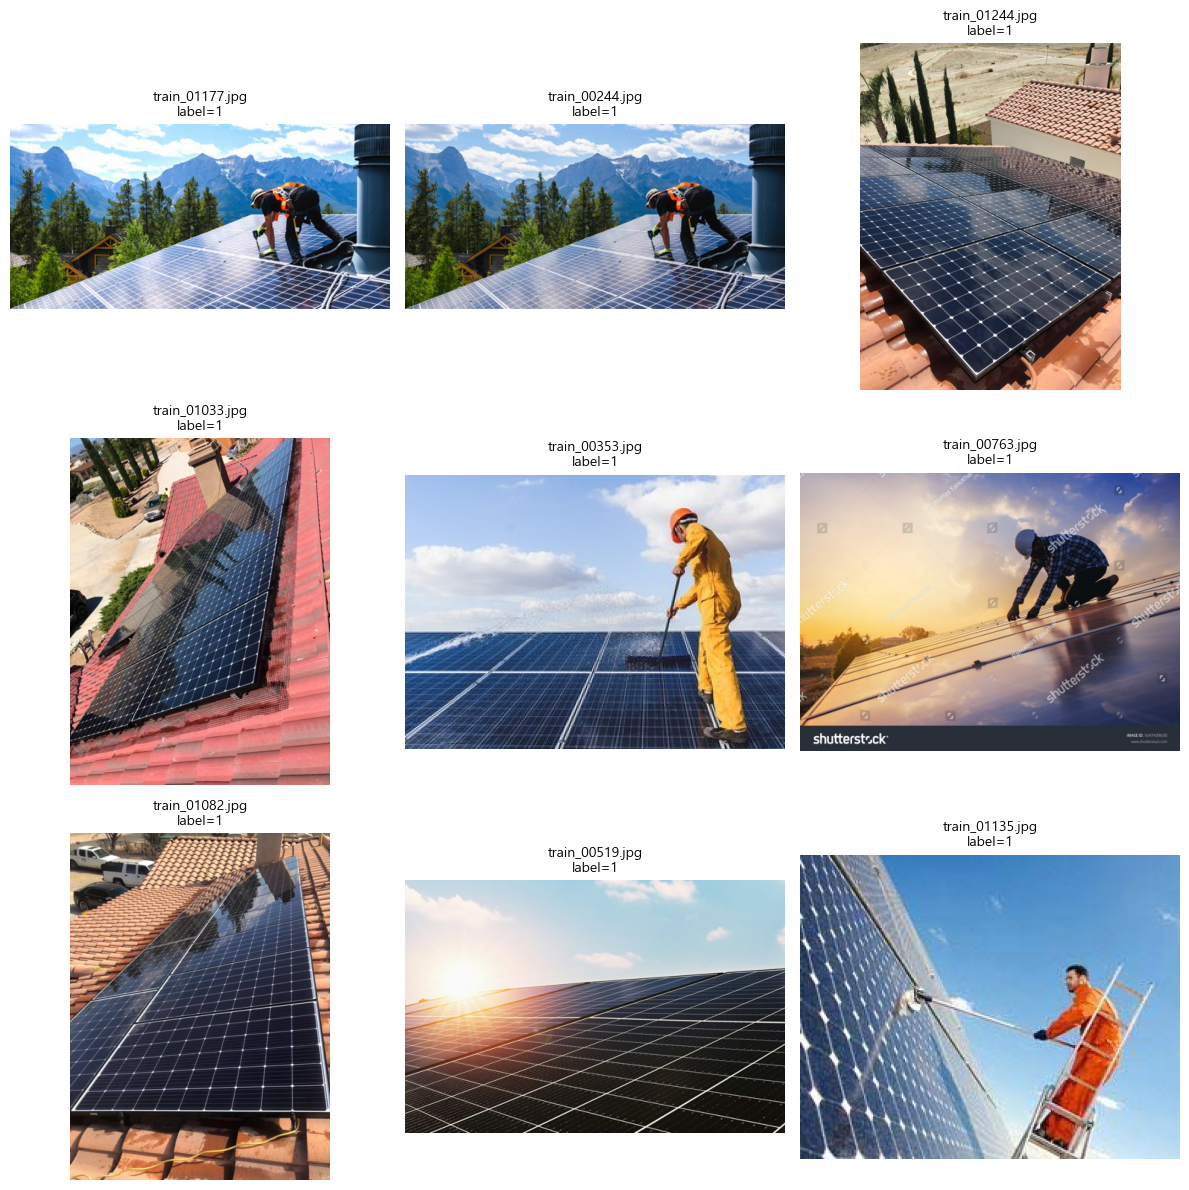

In [56]:
top_mislabel = train_labels.sort_values('mislabel_score', ascending=False).head(9)

fig, axes = plt.subplots(3, 3, figsize=(12,12))
for ax, (_, row) in zip(axes.flatten(), top_mislabel.iterrows()):
    img = Image.open(os.path.join(train_dir, row['fname']))
    ax.imshow(img)
    ax.set_title(f"{row['fname']}\nlabel={row[target_col]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [57]:
# dup_df_final 생성 (dup_score가 이미 dup_df에 있다면)
dup_df_final = dup_df[['fname', 'dup_score']].copy()
print(dup_df_final.shape)
dup_df_final.head()

(1366, 2)


,fname,dup_score
0,train_00000.jpg,-18
1,train_00001.jpg,-18
2,train_00002.jpg,-18
3,train_00003.jpg,-20
4,train_00004.jpg,-18


In [58]:
# dup_score, ood_score와 병합해서 확인
train_labels_merged = train_labels.merge(dup_df_final, on='fname', how='left')
train_labels_merged = train_labels_merged.merge(ood_df_final, on='fname', how='left')

# mislabel 상위 후보들이 dup/ood 점수도 높은지 확인
top_mislabel_check = train_labels_merged.sort_values('mislabel_score', ascending=False).head(20)
print(top_mislabel_check[['fname', 'mislabel_score', 'dup_score', 'ood_score']])

                fname  mislabel_score  dup_score    ood_score
1177  train_01177.jpg        0.999612         -4   863.166667
244   train_00244.jpg        0.999550         -4   794.500000
1244  train_01244.jpg        0.999409        -18   629.833333
1033  train_01033.jpg        0.999067        -18   732.500000
353   train_00353.jpg        0.998472        -18   518.500000
763   train_00763.jpg        0.998273        -18  1255.000000
1082  train_01082.jpg        0.998246        -16   904.833333
519   train_00519.jpg        0.998126        -18   625.833333
1135  train_01135.jpg        0.997981          0   764.833333
395   train_00395.jpg        0.997708        -16   818.833333
356   train_00356.jpg        0.997649        -18   770.833333
853   train_00853.jpg        0.996971        -18   715.833333
794   train_00794.jpg        0.996970        -18   914.166667
25    train_00025.jpg        0.996740        -14   877.833333
228   train_00228.jpg        0.996656        -18   805.500000
1242  tr

In [59]:
for var in ['path', 'train_dir', 'test_dir', 'train_labels', 'hashes', 'embeddings', 'dup_df', 'ood_df', 'pred_probs']:
    print(var, ':', var in dir())

path : True
train_dir : True
test_dir : True
train_labels : True
hashes : True
embeddings : True
dup_df : True
ood_df : True
pred_probs : True


In [60]:
import imagehash
from PIL import Image

hashes = {}
for fname in os.listdir(train_dir):
    img = Image.open(os.path.join(train_dir, fname))
    h = imagehash.phash(img)
    hashes[fname] = h

print(f'해시 계산 완료: {len(hashes)}개')

해시 계산 완료: 1366개


In [62]:
fname_list = list(hashes.keys())
min_dist_dict = {}

for i, f1 in enumerate(fname_list):
    min_d = 999
    for f2 in fname_list:
        if f1 == f2:
            continue
        d = hashes[f1] - hashes[f2]
        if d < min_d:
            min_d = d
    min_dist_dict[f1] = min_d

dup_df = pd.DataFrame(list(min_dist_dict.items()), columns=['fname', 'min_hash_dist'])
dup_df['dup_score'] = -dup_df['min_hash_dist']

print(dup_df.shape)
dup_df.head()

(1366, 3)


,fname,min_hash_dist,dup_score
0,train_00000.jpg,18,-18
1,train_00001.jpg,18,-18
2,train_00002.jpg,18,-18
3,train_00003.jpg,20,-20
4,train_00004.jpg,18,-18


In [63]:
dup_df.to_csv('trackB/dup_df.csv', index=False)
ood_df.to_csv('trackB/ood_df.csv', index=False)

print('저장 완료')

저장 완료


dup_df_final, ood_df_final 생성

In [64]:
dup_df_final = dup_df[['fname', 'dup_score']].copy()
ood_df_final = ood_df[['fname', 'ood_score_v2']].rename(columns={'ood_score_v2': 'ood_score'})

print(dup_df_final.shape, ood_df_final.shape)

(1366, 2) (1366, 2)


mislabel_score와 병합해서 겹치는 정도 확인

In [65]:
train_labels_merged = train_labels.merge(dup_df_final, on='fname', how='left')
train_labels_merged = train_labels_merged.merge(ood_df_final, on='fname', how='left')

top_mislabel_check = train_labels_merged.sort_values('mislabel_score', ascending=False).head(20)
print(top_mislabel_check[['fname', 'mislabel_score', 'dup_score', 'ood_score']])

                fname  mislabel_score  dup_score    ood_score
1177  train_01177.jpg        0.999612         -4   863.166667
244   train_00244.jpg        0.999550         -4   794.500000
1244  train_01244.jpg        0.999409        -18   629.833333
1033  train_01033.jpg        0.999067        -18   732.500000
353   train_00353.jpg        0.998472        -18   518.500000
763   train_00763.jpg        0.998273        -18  1255.000000
1082  train_01082.jpg        0.998246        -16   904.833333
519   train_00519.jpg        0.998126        -18   625.833333
1135  train_01135.jpg        0.997981          0   764.833333
395   train_00395.jpg        0.997708        -16   818.833333
356   train_00356.jpg        0.997649        -18   770.833333
853   train_00853.jpg        0.996971        -18   715.833333
794   train_00794.jpg        0.996970        -18   914.166667
25    train_00025.jpg        0.996740        -14   877.833333
228   train_00228.jpg        0.996656        -18   805.500000
1242  tr

3개 상관관계

In [66]:
correlation = train_labels_merged[['mislabel_score', 'dup_score', 'ood_score']].corr()
print(correlation)

                mislabel_score  dup_score  ood_score
mislabel_score        1.000000  -0.147584  -0.002137
dup_score            -0.147584   1.000000   0.053869
ood_score            -0.002137   0.053869   1.000000


# **평가지표**

In [67]:
from sklearn.metrics import average_precision_score
import numpy as np

def compute_axis_ap(y_true, y_score):
    """
    y_true: 1=오염(중복/OOD/mislabel), 0=정상 인 정답 배열
    y_score: 예측한 의심 점수 (높을수록 오염 의심)
    """
    return average_precision_score(y_true, y_score)


def compute_final_score(y_true_dict, y_score_dict):
    """
    y_true_dict, y_score_dict: {'mislabel': ..., 'dup': ..., 'ood': ...} 형태
    각 축의 AP를 계산하고 평균을 반환
    """
    aps = {}
    for axis in ['mislabel', 'dup', 'ood']:
        ap = compute_axis_ap(y_true_dict[axis], y_score_dict[axis])
        aps[axis] = ap
        print(f'{axis}_AP: {ap:.4f}')

    final_score = np.mean(list(aps.values()))
    print(f'최종 점수 (평균 AP): {final_score:.4f}')
    return final_score, aps

In [68]:
# 지금까지 직접 확인한 진짜 중복 이미지들 (1=중복 의심, 나머지는 0으로 가정)
known_dup_fnames = ['train_00007.jpg', 'train_00301.jpg', 'train_00086.jpg', 'train_01205.jpg',
                     'train_00257.jpg', 'train_01055.jpg', 'train_00236.jpg',
                     'train_00798.jpg', 'train_00011.jpg', 'train_00258.jpg', 'train_00605.jpg']

dup_df_final['y_true_approx'] = dup_df_final['fname'].isin(known_dup_fnames).astype(int)

approx_ap = average_precision_score(dup_df_final['y_true_approx'], dup_df_final['dup_score'])
print(f'dup_score 약식 AP (직접 확인한 샘플 기준): {approx_ap:.4f}')

dup_score 약식 AP (직접 확인한 샘플 기준): 0.0419


In [88]:
print('train 이미지 수:', len(os.listdir(train_dir)))

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


import kagglehub
path = kagglehub.competition_download('rs-18-track-a')

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
train_labels = pd.read_csv(os.path.join(path, 'train_labels.csv'))

print('복구 완료:', path)


train 이미지 수: 1366
복구 완료: C:\Users\H11\.cache\kagglehub\competitions\rs-18-track-a


# **dup_score 계산 (test이미지)**

In [89]:
import imagehash

test_hashes = {}
for fname in os.listdir(test_dir):
    img = Image.open(os.path.join(test_dir, fname))
    h = imagehash.phash(img)
    test_hashes[fname] = h

# train + test 해시 합치기
all_hashes = {**hashes, **test_hashes}
print(f'전체 해시 수: {len(all_hashes)} (train: {len(hashes)}, test: {len(test_hashes)})')

전체 해시 수: 1834 (train: 1366, test: 468)


In [90]:
# test 이미지마다 전체(train+test, 자기 자신 제외)에서 최근접 거리 계산
test_min_dist = {}
all_fnames = list(all_hashes.keys())

for f1 in test_hashes.keys():
    min_d = 999
    for f2 in all_fnames:
        if f1 == f2:
            continue
        d = all_hashes[f1] - all_hashes[f2]
        if d < min_d:
            min_d = d
    test_min_dist[f1] = min_d

test_dup_df = pd.DataFrame(list(test_min_dist.items()), columns=['fname', 'min_hash_dist'])
test_dup_df['dup_score'] = -test_dup_df['min_hash_dist']
print(test_dup_df.shape)
test_dup_df.head()

(468, 3)


,fname,min_hash_dist,dup_score
0,test_00000.jpg,20,-20
1,test_00001.jpg,18,-18
2,test_00002.jpg,18,-18
3,test_00003.jpg,18,-18
4,test_00004.jpg,18,-18


In [91]:
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

test_embeddings = {}
with torch.no_grad():
    for fname in os.listdir(test_dir):
        img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
        x = transform(img).unsqueeze(0)
        emb = model(x).squeeze().numpy()
        test_embeddings[fname] = emb

print(f'test 임베딩 추출 완료: {len(test_embeddings)}개')

test 임베딩 추출 완료: 468개


In [92]:
# train의 centroid를 기준으로 사용 (정상 분포의 기준점)
train_emb_matrix = np.array([embeddings[f] for f in embeddings.keys()])
centroid = train_emb_matrix.mean(axis=0)

test_fname_list = list(test_embeddings.keys())
test_emb_matrix = np.array([test_embeddings[f] for f in test_fname_list])

test_centroid_dist = np.linalg.norm(test_emb_matrix - centroid, axis=1)

test_ood_df = pd.DataFrame({'fname': test_fname_list, 'centroid_dist': test_centroid_dist})

In [93]:
# KNN은 train 전체를 이웃 후보로 사용
from sklearn.neighbors import NearestNeighbors

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(train_emb_matrix)  # train 기준으로 학습
dists, idxs = nbrs.kneighbors(test_emb_matrix)
test_knn_dist = dists.mean(axis=1)

test_ood_df['knn_dist'] = test_knn_dist

In [101]:
# !pip install -q pytesseract
# !apt-get install -y tesseract-ocr -q
import pytesseract

test_text_lengths = {}
for fname in os.listdir(test_dir):
    img = Image.open(os.path.join(test_dir, fname)).convert('RGB')
    text = pytesseract.image_to_string(img)
    test_text_lengths[fname] = len(text.strip())

test_ood_df['text_length'] = test_ood_df['fname'].map(test_text_lengths)

In [102]:
from scipy.stats import rankdata

test_ood_df['centroid_rank'] = rankdata(test_ood_df['centroid_dist'])
test_ood_df['knn_rank'] = rankdata(test_ood_df['knn_dist'])
test_ood_df['text_rank'] = rankdata(test_ood_df['text_length'])

test_ood_df['ood_score'] = (test_ood_df['centroid_rank'] + test_ood_df['knn_rank'] + test_ood_df['text_rank']) / 3
test_ood_df.head()

,fname,centroid_dist,knn_dist,text_length,centroid_rank,knn_rank,text_rank,ood_score
0,test_00000.jpg,12.742955,12.238483,0,61.0,29.0,223.0,104.333333
1,test_00001.jpg,11.587584,12.151988,0,18.0,24.0,223.0,88.333333
2,test_00002.jpg,13.908195,16.288155,0,145.0,370.0,223.0,246.000000
3,test_00003.jpg,15.938329,15.213120,0,318.0,280.0,223.0,273.666667
4,test_00004.jpg,16.670321,16.430531,0,361.0,380.0,223.0,321.333333


# **mislaebl_score 계산(test 이미지)**

In [100]:
print(train_labels.columns)
print(type(train_labels))

print(train_labels.head())


Index(['id', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
            id  label
0  train_00000      0
1  train_00001      1
2  train_00002      0
3  train_00003      1
4  train_00004      1


In [103]:
# # train 전체로 모델 재학습 (K-fold 대신 전체 데이터 사용)


# train_ds_full = PanelDataset(train_labels, train_dir, transform)
# train_loader_full = DataLoader(train_ds_full, batch_size=32, shuffle=True)

# model_final = models.resnet18(pretrained=True)
# model_final.fc = nn.Linear(model_final.fc.in_features, 2)
# model_final = model_final.to(device)

# optimizer = torch.optim.Adam(model_final.parameters(), lr=1e-4)
# criterion = nn.CrossEntropyLoss()

# model_final.train()
# for epoch in range(3):
#     total_loss = 0
#     for imgs, labels in train_loader_full:
#         imgs, labels = imgs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model_final(imgs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader_full):.4f}')

In [104]:
print('test_ood_df' in dir())
if 'test_ood_df' in dir():
    print(test_ood_df.shape)
    print(test_ood_df.columns.tolist())
    test_ood_df.head()

True
(468, 8)
['fname', 'centroid_dist', 'knn_dist', 'text_length', 'centroid_rank', 'knn_rank', 'text_rank', 'ood_score']


# **test 이미지에 대한 예측확률**

In [105]:
# 1. test 이미지에 대해 예측 확률 산출
class TestPanelDataset(Dataset):
    def __init__(self, fnames, img_dir, transform):
        self.fnames = fnames
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        img = self.transform(img)
        return img, fname

test_fnames = os.listdir(test_dir)
test_ds = TestPanelDataset(test_fnames, test_dir, transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model_final.eval()
test_pred_probs = {}

with torch.no_grad():
    for imgs, fnames in test_loader:
        imgs = imgs.to(device)
        outputs = model_final(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        for fname, prob in zip(fnames, probs):
            test_pred_probs[fname] = prob

print(f'test 예측 완료: {len(test_pred_probs)}개')

test 예측 완료: 468개


In [109]:
# 2. mislabel_score 계산
mislabel_records = []
for fname, prob in test_pred_probs.items():
    confidence = abs(prob[1] - 0.5)
    mislabel_score = 1 - (confidence * 2)
    mislabel_records.append({'fname': fname, 'mislabel_score': mislabel_score})

test_mislabel_df = pd.DataFrame(mislabel_records)
test_mislabel_df.head()

,fname,mislabel_score
0,test_00000.jpg,0.411354
1,test_00001.jpg,0.293679
2,test_00002.jpg,0.562747
3,test_00003.jpg,0.248061
4,test_00004.jpg,0.878854


In [118]:
sample_submission = pd.read_csv(os.path.join(path, 'sample_submission.csv'))
print(sample_submission.shape)
print(sample_submission['id'].head(10))
print(sample_submission['id'].tail(10))

print('test 폴더 이미지 수:', len(os.listdir(test_dir)))
print('train 이미지 수:', len(os.listdir(train_dir)))

(468, 2)
0    test_00000
1    test_00001
2    test_00002
3    test_00003
4    test_00004
5    test_00005
6    test_00006
7    test_00007
8    test_00008
9    test_00009
Name: id, dtype: object
458    test_00460
459    test_00461
460    test_00462
461    test_00463
462    test_00464
463    test_00465
464    test_00466
465    test_00467
466    test_00468
467    test_00469
Name: id, dtype: object
test 폴더 이미지 수: 468
train 이미지 수: 1366


In [119]:
# 3. 세 점수 병합
test_dup_df['id'] = test_dup_df['fname'].str.replace('.jpg', '', regex=False)
test_ood_df['id'] = test_ood_df['fname'].str.replace('.jpg', '', regex=False)
test_mislabel_df['id'] = test_mislabel_df['fname'].str.replace('.jpg', '', regex=False)

submission = sample_submission[['id']].copy()
submission = submission.merge(test_mislabel_df[['id', 'mislabel_score']], on='id', how='left')
submission = submission.merge(test_dup_df[['id', 'dup_score']], on='id', how='left')
submission = submission.merge(test_ood_df[['id', 'ood_score']], on='id', how='left')

print(submission.shape)
print(submission.isnull().sum())
submission.head()

(468, 4)
id                0
mislabel_score    0
dup_score         0
ood_score         0
dtype: int64


,id,mislabel_score,dup_score,ood_score
0,test_00000,0.411354,-20,104.333333
1,test_00001,0.293679,-18,88.333333
2,test_00002,0.562747,-18,246.000000
3,test_00003,0.248061,-18,273.666667
4,test_00004,0.878854,-18,321.333333


In [120]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
submission[['mislabel_score', 'dup_score', 'ood_score']] = scaler.fit_transform(
    submission[['mislabel_score', 'dup_score', 'ood_score']]
)

submission.head()

,id,mislabel_score,dup_score,ood_score
0,test_00000,0.347394,0.0,0.079245
1,test_00001,0.208902,0.1,0.033962
2,test_00002,0.525568,0.1,0.480189
3,test_00003,0.155214,0.1,0.558491
4,test_00004,0.897597,0.1,0.693396


In [121]:
submission.to_csv('trackB/submission_abc.csv', index=False)
print('저장 완료')
print(submission.shape)
submission.head()

저장 완료
(468, 4)


,id,mislabel_score,dup_score,ood_score
0,test_00000,0.347394,0.0,0.079245
1,test_00001,0.208902,0.1,0.033962
2,test_00002,0.525568,0.1,0.480189
3,test_00003,0.155214,0.1,0.558491
4,test_00004,0.897597,0.1,0.693396


In [122]:
for var in ['train_labels', 'dup_df', 'ood_df']:
    print(var, ':', var in dir())

if 'train_labels' in dir():
    print(train_labels.columns.tolist())
if 'dup_df' in dir():
    print(dup_df.columns.tolist())
if 'ood_df' in dir():
    print(ood_df.columns.tolist())

train_labels : True
dup_df : True
ood_df : True
['id', 'label']
['fname', 'min_hash_dist', 'dup_score']
['fname', 'centroid_dist', 'knn_dist', 'centroid_rank', 'knn_rank', 'ood_score', 'text_length', 'text_rank', 'ood_score_v2']


# **3개 Score 계산(train data)**

In [125]:
print(train_labels['id'].head())
print(train_labels['fname'].head())

0    train_00000
1    train_00001
2    train_00002
3    train_00003
4    train_00004
Name: id, dtype: object
0    train_00000.jpg
1    train_00001.jpg
2    train_00002.jpg
3    train_00003.jpg
4    train_00004.jpg
Name: fname, dtype: object


In [128]:
dup_df_final = dup_df[['fname', 'dup_score']].copy()
ood_df_final = ood_df[['fname', 'ood_score_v2']].rename(columns={'ood_score_v2': 'ood_score'})

submission = train_labels[['id', 'fname', 'mislabel_score']].copy()
submission = submission.merge(dup_df_final, on='fname', how='left')
submission = submission.merge(ood_df_final, on='fname', how='left')

submission = submission[['id', 'mislabel_score', 'dup_score', 'ood_score']]

print(submission.shape)
print(submission.isnull().sum())
submission.head()

(1366, 4)
id                0
mislabel_score    0
dup_score         0
ood_score         0
dtype: int64


,id,mislabel_score,dup_score,ood_score
0,train_00000,0.352441,-18,685.166667
1,train_00001,0.832797,-18,374.166667
2,train_00002,0.192495,-18,995.166667
3,train_00003,0.029136,-20,1024.500000
4,train_00004,0.940523,-18,732.833333


In [129]:
print('submission id 샘플:', submission['id'].head(3).tolist())
print('sample_submission id 샘플:', sample_submission['id'].head(3).tolist())
print('submission 행 수:', submission.shape[0])
print('sample_submission 행 수:', sample_submission.shape[0])

submission id 샘플: ['train_00000', 'train_00001', 'train_00002']
sample_submission id 샘플: ['test_00000', 'test_00001', 'test_00002']
submission 행 수: 1366
sample_submission 행 수: 468


In [131]:
submission.to_csv('trackB/submission_train.csv', index=False)
print('저장 완료')
print(submission.shape)
submission.head()

저장 완료
(1366, 4)


,id,mislabel_score,dup_score,ood_score
0,train_00000,0.352441,-18,685.166667
1,train_00001,0.832797,-18,374.166667
2,train_00002,0.192495,-18,995.166667
3,train_00003,0.029136,-20,1024.500000
4,train_00004,0.940523,-18,732.833333


In [8]:
scores = pd.read_csv('trackB/submission_train.csv',)
scores.head

# 상위 10%를 이상치로 간주하는 설정 (필요에 따라 0.05, 0.15 등으로 조절)
p_mislabel = 0.10
p_dup = 0.10
p_ood = 0.10

# 각 스코어의 임계값 계산
mislabel_threshold = scores['mislabel_score'].quantile(1 - p_mislabel)
dup_threshold = scores['dup_score'].quantile(1 - p_dup)
ood_threshold = scores['ood_score'].quantile(1 - p_ood)

# 조건 적용 (논리 연산자 '|' 대신 '&'를 쓰거나, 기준을 더 높여서 범위를 좁힘)
# 예: 모든 조건이 동시에 나쁠 때만 제거하거나, 기준점을 높임
is_outlier = (
    (scores['mislabel_score'] > mislabel_threshold) | 
    (scores['ood_score'] > ood_threshold)
)

outlier_data = scores[is_outlier]
clean_data = scores[~is_outlier]

print(f"이상치 데이터 개수: {len(outlier_data)}")
print(f"정제된 데이터 개수: {len(clean_data)}")

이상치 데이터 개수: 261
정제된 데이터 개수: 1105


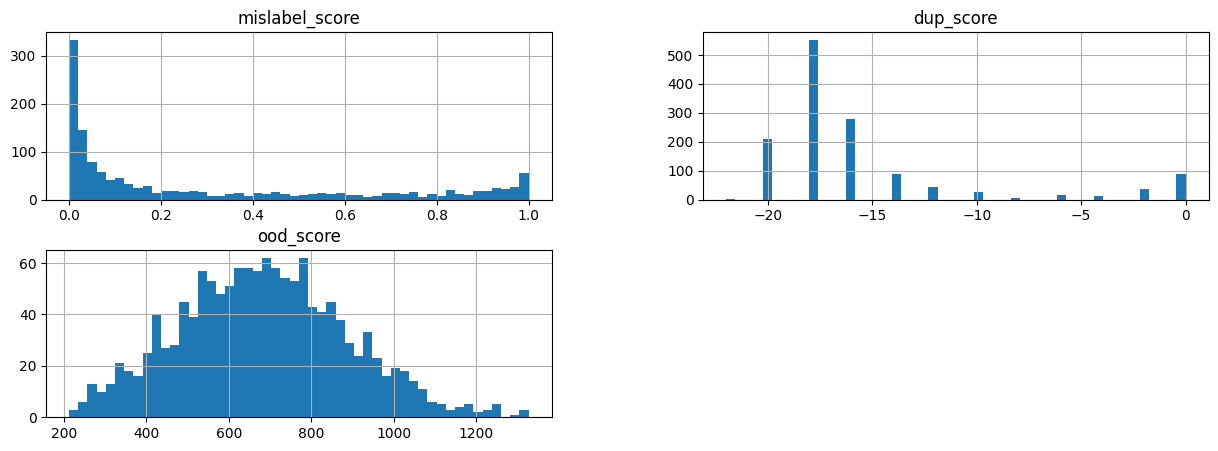

In [9]:
# 스코어 분포 시각화 예시
scores[['mislabel_score', 'dup_score', 'ood_score']].hist(bins=50, figsize=(15, 5))
plt.show()

In [11]:
train_meta = pd.read_csv('C:/Users/H11/.cache/kagglehub/competitions/rs-18-track-b/train_labels.csv')
final_train_df = train_meta[train_meta['id'].isin(clean_data['id'])]
final_train_df.to_csv('train_SJ_cleaned.csv', index=False)